In [ ]:
import pandas as pd

NPI = pd.read_csv(r'data/decoupling/data_手动修正.csv', index_col='Unnamed: 0')
NPI.rename(columns={
    'time': 'NPI',
}, inplace=True)
NPI

,city,intensity,umap_1,umap_2,NPI,log_intensity,quartile,color,city_en
0,梅州,13170,3.175451,6.958565,132,4.119586,Q2,#2ca02c,Meizhou
1,吕梁,17040,2.973684,3.357782,120,4.231470,Q2,#2ca02c,Luliang
2,舟山,31566,5.663746,-0.090759,102,4.499220,Q3,#ff7f0e,Zhoushan
3,朝阳,7912,2.659808,1.873272,101,3.898286,Q1,#1f77b4,Chaoyang
4,广安,6443,3.196313,6.344944,119,3.809088,Q1,#1f77b4,Guang'an
...,...,...,...,...,...,...,...,...,...
271,陇南,7059,4.239348,5.974148,111,3.848743,Q1,#1f77b4,Longnan
272,保山,11598,6.201652,4.471026,119,4.064383,Q2,#2ca02c,Baoshan
273,遂宁,7474,1.444519,3.866109,117,3.873553,Q1,#1f77b4,Suining
274,合肥,167171,2.367577,6.124521,117,5.223161,Q4,#d62728,Hefei


In [ ]:
import geopandas as gpd

data = gpd.read_file(r'data\result3\regression.shp')
data.rename(columns={
    '地区生': 'GDP',
    '第一产': 'PctPrimary',
    '第二产': 'PctSecondary',
    '第三产': 'PctTertiary',
    'Pre': 'Precipitation'
}, inplace=True)
data['GDP'] = data['GDP'] / 100 #(M yuan)
data

,name,gb,contain_ci,lat,lng,delay,city,time,seconds,GDP,PctPrimary,PctSecondary,PctTertiary,LST,Precipitation,geometry
0,梅州市,156441400,梅州,24.294178,116.129537,0.0,梅州,23:12:13,4333.0,140800.0,18.89,31.53,49.58,16.270223,3530.427525,"POLYGON Z ((115.88406 24.92896 0, 115.89031 24..."
1,吕梁市,156141100,吕梁,37.524498,111.150450,0.0,吕梁,23:00:05,3605.0,236600.0,4.64,67.35,28.01,5.479939,962.971386,"POLYGON Z ((111.20539 38.72164 0, 111.20739 38..."
2,舟山市,156330900,舟山,29.990912,122.213556,0.0,舟山,22:42:52,2572.0,210100.0,8.75,47.81,43.44,13.088743,2625.939252,"MULTIPOLYGON Z (((122.25205 29.69094 0, 122.23..."
3,朝阳市,156211300,朝阳,41.579821,120.457499,0.0,朝阳,22:41:11,2471.0,104400.0,23.79,27.95,48.26,2.082538,1088.546691,"POLYGON Z ((119.6002 42.27468 0, 119.60812 42...."
4,广安市,156511600,广安,30.461746,106.639553,0.0,广安,22:59:04,3544.0,151300.0,16.38,30.42,53.20,14.556926,2823.592104,"MULTIPOLYGON Z (((107.26394 30.38628 0, 107.27..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
307,陇南市,156621200,陇南,33.376032,104.966864,0.0,陇南,22:51:57,3117.0,60300.0,19.24,26.12,54.64,6.851463,989.385416,"POLYGON Z ((105.24292 34.52701 0, 105.2453 34...."
308,保山市,156530500,保山,25.117858,99.168012,0.0,保山,22:59:24,3564.0,125400.0,23.57,36.45,39.98,12.283457,2152.772421,"POLYGON Z ((98.7239 25.82049 0, 98.7109 25.806..."
309,遂宁市,156510900,遂宁,30.539098,105.599422,0.0,遂宁,22:57:59,3479.0,171500.0,12.91,45.66,41.43,14.617471,2579.975818,"MULTIPOLYGON Z (((105.90684 30.48512 0, 105.91..."
310,合肥市,156340100,合肥,31.826578,117.233443,0.0,合肥,22:57:01,3421.0,1267400.0,2.98,36.63,60.40,12.139336,2906.125367,"POLYGON Z ((117.19746 32.52641 0, 117.20584 32..."


In [ ]:
sunsettime = gpd.read_file(r'data/result3/sunset.shp')
sunsettime['time'] = pd.to_timedelta(sunsettime['starting']) - pd.Timedelta(hours=6)

sunsettime['time'] = sunsettime['time'].mod(pd.Timedelta('1D'))
sunsettime['time'] = sunsettime['time'].astype(str)
sunsettime['time'] = sunsettime['time'].apply(lambda x: str(x).split()[-1])
sunsettime['time'] = pd.to_timedelta(sunsettime['time'])
target_time = pd.to_timedelta('21:00:00')
sunsettime['Sunset'] = (target_time - sunsettime['time']).dt.total_seconds().fillna(0).astype(int) / 60
sunsettime.rename(columns={
    'contain_ci': 'city',
}, inplace=True)
sunsettime

,name,gb,city,lat,lng,starting,ending,geometry,time,Sunset
0,梅州市,156441400,梅州,24.294178,116.129537,22:19:45,04:19:45,"POLYGON Z ((115.88406 24.92896 0, 115.89031 24...",0 days 16:19:45,280.250000
1,鄂州市,156420700,鄂州,30.396572,114.901607,22:25:05,04:25:05,"POLYGON Z ((114.83199 30.5678 0, 114.82968 30....",0 days 16:25:05,274.916667
2,吕梁市,156141100,吕梁,37.524498,111.150450,22:40:44,04:40:44,"POLYGON Z ((111.20539 38.72164 0, 111.20739 38...",0 days 16:40:44,259.266667
3,舟山市,156330900,舟山,29.990912,122.213556,21:55:48,03:55:48,"MULTIPOLYGON Z (((122.25205 29.69094 0, 122.23...",0 days 15:55:48,304.200000
4,朝阳市,156211300,朝阳,41.579821,120.457499,22:03:59,04:03:59,"POLYGON Z ((119.6002 42.27468 0, 119.60812 42....",0 days 16:03:59,296.016667
...,...,...,...,...,...,...,...,...,...,...
367,陇南市,156621200,陇南,33.376032,104.966864,23:05:04,05:05:04,"POLYGON Z ((105.24292 34.52701 0, 105.2453 34....",0 days 17:05:04,234.933333
368,保山市,156530500,保山,25.117858,99.168012,23:27:38,05:27:38,"POLYGON Z ((98.7239 25.82049 0, 98.7109 25.806...",0 days 17:27:38,212.366667
369,遂宁市,156510900,遂宁,30.539098,105.599422,23:02:18,05:02:18,"MULTIPOLYGON Z (((105.90684 30.48512 0, 105.91...",0 days 17:02:18,237.700000
370,合肥市,156340100,合肥,31.826578,117.233443,22:15:52,04:15:52,"POLYGON Z ((117.19746 32.52641 0, 117.20584 32...",0 days 16:15:52,284.133333


In [4]:
data = data.merge(sunsettime[['city', 'Sunset']], on='city', how='left')
data = data.merge(NPI[['city', 'NPI']], on='city', how='right')
data = data.to_crs("EPSG:4539") # CGCS2000_Albers

data['centroid'] = data.geometry.centroid


data['X'] = data.centroid.x
data['Y'] = data.centroid.y

data = data.drop(columns=['centroid'])

data

,name,gb,contain_ci,lat,lng,delay,city,time,seconds,GDP,PctPrimary,PctSecondary,PctTertiary,LST,Precipitation,geometry,Sunset,NPI,X,Y
0,梅州市,156441400,梅州,24.294178,116.129537,0.0,梅州,23:12:13,4333.0,140800.0,18.89,31.53,49.58,16.270223,3530.427525,"POLYGON Z ((3172852.759 3024945.608 0, 3173559...",280.250000,132,3.211471e+06,2.943171e+06
1,吕梁市,156141100,吕梁,37.524498,111.150450,0.0,吕梁,23:00:05,3605.0,236600.0,4.64,67.35,28.01,5.479939,962.971386,"POLYGON Z ((2352673.622 4507687.604 0, 2353099...",259.266667,120,2.386389e+06,4.391207e+06
2,舟山市,156330900,舟山,29.990912,122.213556,0.0,舟山,22:42:52,2572.0,210100.0,8.75,47.81,43.44,13.088743,2625.939252,"MULTIPOLYGON Z (((3704161.177 3765051.612 0, 3...",304.200000,102,3.681404e+06,3.809924e+06
3,朝阳市,156211300,朝阳,41.579821,120.457499,0.0,朝阳,22:41:11,2471.0,104400.0,23.79,27.95,48.26,2.082538,1088.546691,"POLYGON Z ((2947975.461 5128461.903 0, 2949669...",296.016667,101,3.015129e+06,5.056344e+06
4,广安市,156511600,广安,30.461746,106.639553,0.0,广安,22:59:04,3544.0,151300.0,16.38,30.42,53.20,14.556926,2823.592104,"MULTIPOLYGON Z (((2171518.404 3492793.408 0, 2...",241.866667,119,2.111941e+06,3.488139e+06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
271,陇南市,156621200,陇南,33.376032,104.966864,0.0,陇南,22:51:57,3117.0,60300.0,19.24,26.12,54.64,6.851463,989.385416,"POLYGON Z ((1905316.581 3929585.263 0, 1905738...",234.933333,111,1.919503e+06,3.824532e+06
272,保山市,156530500,保山,25.117858,99.168012,0.0,保山,22:59:24,3564.0,125400.0,23.57,36.45,39.98,12.283457,2152.772421,"POLYGON Z ((1376855.172 2886172.787 0, 1375642...",212.366667,119,1.408406e+06,2.793542e+06
273,遂宁市,156510900,遂宁,30.539098,105.599422,0.0,遂宁,22:57:59,3479.0,171500.0,12.91,45.66,41.43,14.617471,2579.975818,"MULTIPOLYGON Z (((2036812.985 3483897.241 0, 2...",237.700000,117,1.992019e+06,3.494326e+06
274,合肥市,156340100,合肥,31.826578,117.233443,0.0,合肥,22:57:01,3421.0,1267400.0,2.98,36.63,60.40,12.139336,2906.125367,"POLYGON Z ((3094538.255 3947390.977 0, 3095675...",284.133333,117,3.134681e+06,3.862999e+06


In [ ]:
older = pd.read_csv(r'data/result3/第七次人口普查分县数据.csv')
older.rename(columns={
    '地区': 'name',
    '65岁及以上人口比重（%）':'PctOlderAdult'
}, inplace=True)

In [6]:
data = data.merge(older, on='name', how='left')
data

,name,gb,contain_ci,lat,lng,delay,city,time,seconds,GDP,...,PctSecondary,PctTertiary,LST,Precipitation,geometry,Sunset,NPI,X,Y,PctOlderAdult
0,梅州市,156441400,梅州,24.294178,116.129537,0.0,梅州,23:12:13,4333.0,140800.0,...,31.53,49.58,16.270223,3530.427525,"POLYGON Z ((3172852.759 3024945.608 0, 3173559...",280.250000,132,3.211471e+06,2.943171e+06,14.41
1,吕梁市,156141100,吕梁,37.524498,111.150450,0.0,吕梁,23:00:05,3605.0,236600.0,...,67.35,28.01,5.479939,962.971386,"POLYGON Z ((2352673.622 4507687.604 0, 2353099...",259.266667,120,2.386389e+06,4.391207e+06,11.62
2,舟山市,156330900,舟山,29.990912,122.213556,0.0,舟山,22:42:52,2572.0,210100.0,...,47.81,43.44,13.088743,2625.939252,"MULTIPOLYGON Z (((3704161.177 3765051.612 0, 3...",304.200000,102,3.681404e+06,3.809924e+06,17.09
3,朝阳市,156211300,朝阳,41.579821,120.457499,0.0,朝阳,22:41:11,2471.0,104400.0,...,27.95,48.26,2.082538,1088.546691,"POLYGON Z ((2947975.461 5128461.903 0, 2949669...",296.016667,101,3.015129e+06,5.056344e+06,15.96
4,广安市,156511600,广安,30.461746,106.639553,0.0,广安,22:59:04,3544.0,151300.0,...,30.42,53.20,14.556926,2823.592104,"MULTIPOLYGON Z (((2171518.404 3492793.408 0, 2...",241.866667,119,2.111941e+06,3.488139e+06,19.57
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
271,陇南市,156621200,陇南,33.376032,104.966864,0.0,陇南,22:51:57,3117.0,60300.0,...,26.12,54.64,6.851463,989.385416,"POLYGON Z ((1905316.581 3929585.263 0, 1905738...",234.933333,111,1.919503e+06,3.824532e+06,12.59
272,保山市,156530500,保山,25.117858,99.168012,0.0,保山,22:59:24,3564.0,125400.0,...,36.45,39.98,12.283457,2152.772421,"POLYGON Z ((1376855.172 2886172.787 0, 1375642...",212.366667,119,1.408406e+06,2.793542e+06,12.59
273,遂宁市,156510900,遂宁,30.539098,105.599422,0.0,遂宁,22:57:59,3479.0,171500.0,...,45.66,41.43,14.617471,2579.975818,"MULTIPOLYGON Z (((2036812.985 3483897.241 0, 2...",237.700000,117,1.992019e+06,3.494326e+06,19.85
274,合肥市,156340100,合肥,31.826578,117.233443,0.0,合肥,22:57:01,3421.0,1267400.0,...,36.63,60.40,12.139336,2906.125367,"POLYGON Z ((3094538.255 3947390.977 0, 3095675...",284.133333,117,3.134681e+06,3.862999e+06,11.99


In [15]:
features = ['LST', 'Sunset', 'PctOlderAdult', 'GDP', 'Precipitation', 'PctTertiary', 'PctPrimary', 'PctSecondary']
X = data[features]
y = data['NPI']

In [16]:
import libpysal
from libpysal import weights
from spreg import ML_Error
import numpy as np
from sklearn.preprocessing import StandardScaler
import warnings

warnings.filterwarnings("ignore", category=RuntimeWarning, message="Method 'bounded' does not support relative tolerance")
coords = np.column_stack((data['X'], data['Y']))
w = weights.distance.KNN.from_array(coords, k=5) 
w.transform = 'R'

X_raw = data[features].values
y_raw = data['NPI'].values.reshape(-1, 1)

scaler_X = StandardScaler()
scaler_y = StandardScaler()


X_scaled = scaler_X.fit_transform(X_raw)
y_scaled = scaler_y.fit_transform(y_raw)

model = ML_Error(y_scaled, X_scaled, w=w, name_y='NPI(scaled)', name_x=features)

# 5. 输出结果
print(model.summary)

ML_Error
REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: ML SPATIAL ERROR (METHOD = full)
------------------------------------------------------------------------------------
Data set            :     unknown
Weights matrix      :     unknown
Dependent Variable  : NPI(scaled)                Number of Observations:         276
Mean dependent var  :      0.0000                Number of Variables   :           9
S.D. dependent var  :      1.0018                Degrees of Freedom    :         267
Pseudo R-squared    :      0.5066
Log likelihood      :   -193.8184
Sigma-square ML     :      0.2044                Akaike info criterion :     405.637
S.E of regression   :      0.4521                Schwarz criterion     :     438.220

------------------------------------------------------------------------------------
            Variable     Coefficient       Std.Error     z-Statistic     Probability
-----------------------------------------------------------------------------------

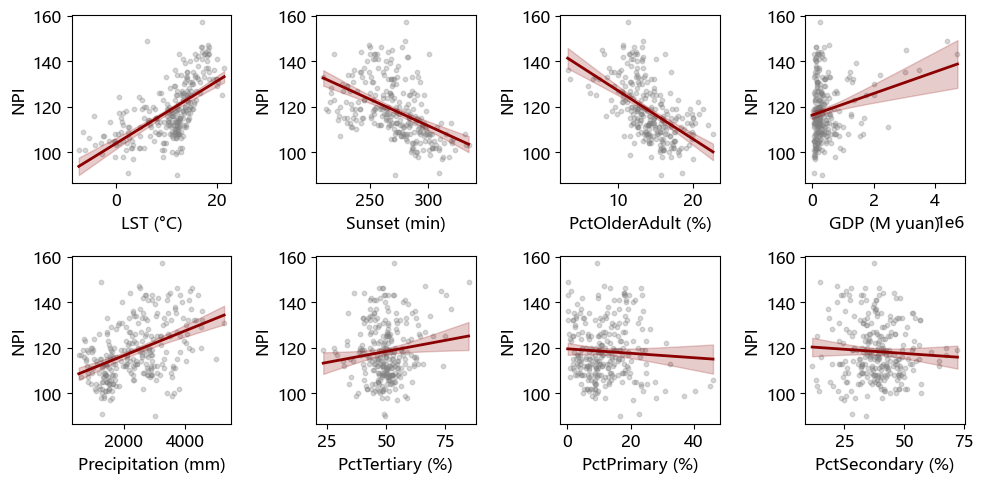

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from pygam import LinearGAM, l
import warnings

warnings.filterwarnings("ignore", category=RuntimeWarning, message="Method 'bounded' does not support relative tolerance")

plt.rcParams['font.sans-serif'] = ['Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams.update({'font.size': 12})

units_list = [' (°C)', ' (min)', ' (%)', ' (M yuan)', ' (mm)', ' (%)', ' (%)', ' (%)']
unit_map = dict(zip(features, units_list))

fig, axes = plt.subplots(2, 4, figsize=(10, 5), dpi=100)
axes = axes.flatten()
plt.subplots_adjust(wspace=0.4, hspace=0.3)

for ax, name in zip(axes, features):
    unit = unit_map[name]
    
    x = data[name].values.reshape(-1, 1)
    
    y = data['NPI'].values.flatten() 

    gam = LinearGAM(l(0)).gridsearch(x, y, progress=False)

    XX = np.linspace(x.min(), x.max(), 200)
    preds = gam.predict(XX)
    ci_lower, ci_upper = gam.confidence_intervals(XX, width=0.95).T

    ax.scatter(x, y, s=10, alpha=0.3, color='gray')

    ax.plot(XX, preds, color='darkred', linewidth=2)
    ax.fill_between(XX, ci_lower, ci_upper, color='darkred', alpha=0.2)


    ax.set_xlabel(name + unit)
    ax.set_ylabel('NPI')

    x_min, x_max = ax.get_xlim()
    
plt.tight_layout()
# plt.savefig('spatial_gam_plot.png', dpi=300, bbox_inches='tight')
plt.show()

In [9]:
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import mean_squared_error, r2_score
from scipy.stats import randint, uniform

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=32)


xgb_model = xgb.XGBRegressor(objective='reg:squarederror', random_state=4)

param_dist = {
    'n_estimators': randint(50, 100),
    'max_depth': randint(3, 6),
    'learning_rate': uniform(0.01, 0.2),
    'subsample': uniform(0.5, 0.4),
    'colsample_bytree': uniform(0.5, 0.4),
    'gamma': uniform(0, 3),
    'reg_alpha': uniform(0, 3),
    'reg_lambda': uniform(0, 3)
}



random_search = RandomizedSearchCV(
    xgb_model,
    param_distributions=param_dist,
    n_iter=50,
    scoring='neg_root_mean_squared_error',
    cv=5,
    verbose=1,
    n_jobs=-1,
    random_state=42
)


random_search.fit(X_train, y_train)

best_model = random_search.best_estimator_

y_train_pred = best_model.predict(X_train)
y_test_pred = best_model.predict(X_test)

train_rmse = mean_squared_error(y_train, y_train_pred, squared=False)
test_rmse = mean_squared_error(y_test, y_test_pred, squared=False)

train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

print("Best Parameters:", random_search.best_params_)
print(f"Training RMSE: {train_rmse:.2f}")
print(f"Test RMSE: {test_rmse:.2f}")
print(f"Training R² Score: {train_r2:.3f}")
print(f"Test R² Score: {test_r2:.3f}")


Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best Parameters: {'colsample_bytree': 0.848584236075087, 'gamma': 2.4110162306973435, 'learning_rate': 0.04731401177720717, 'max_depth': 4, 'n_estimators': 60, 'reg_alpha': 0.9730350630158219, 'reg_lambda': 0.36626386410202005, 'subsample': 0.64251913523079}
Training RMSE: 3.85
Test RMSE: 4.87
Training R² Score: 0.908
Test R² Score: 0.811


d:\Anaconda\envs\py_new\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
d:\Anaconda\envs\py_new\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [10]:
import shap

var = X

background_X = shap.kmeans(var, 150).data

geomlr_explainer = shap.TreeExplainer(best_model)#, background_X)

geomlr_rslt = geomlr_explainer(var)

d:\Anaconda\envs\py_new\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [11]:
geomlr_rslt

.values =
array([[13.524417  ,  1.1011913 , -0.8812391 , ...,  0.36287418,
        -0.22084688, -0.21721862],
       [-3.7418885 , -1.8558954 ,  3.0287507 , ..., -0.15318948,
         0.15053986, -0.05764316],
       [-2.955567  ,  0.7806169 , -4.8041816 , ..., -0.7459773 ,
        -0.02137816,  0.01438527],
       ...,
       [ 1.445513  ,  0.84965307,  2.951593  , ...,  0.17169441,
        -0.20286384, -0.2080209 ],
       [-4.2590585 ,  0.70767707, -1.6216103 , ..., -0.30548862,
         0.03297453,  1.039881  ],
       [-3.9268675 , -1.4225825 ,  4.0332274 , ..., -0.56488246,
         0.03352425, -0.22337152]], dtype=float32)

.base_values =
array([119.046036, 119.046036, 119.046036, 119.046036, 119.046036,
       119.046036, 119.046036, 119.046036, 119.046036, 119.046036,
       119.046036, 119.046036, 119.046036, 119.046036, 119.046036,
       119.046036, 119.046036, 119.046036, 119.046036, 119.046036,
       119.046036, 119.046036, 119.046036, 119.046036, 119.046036,
       119.

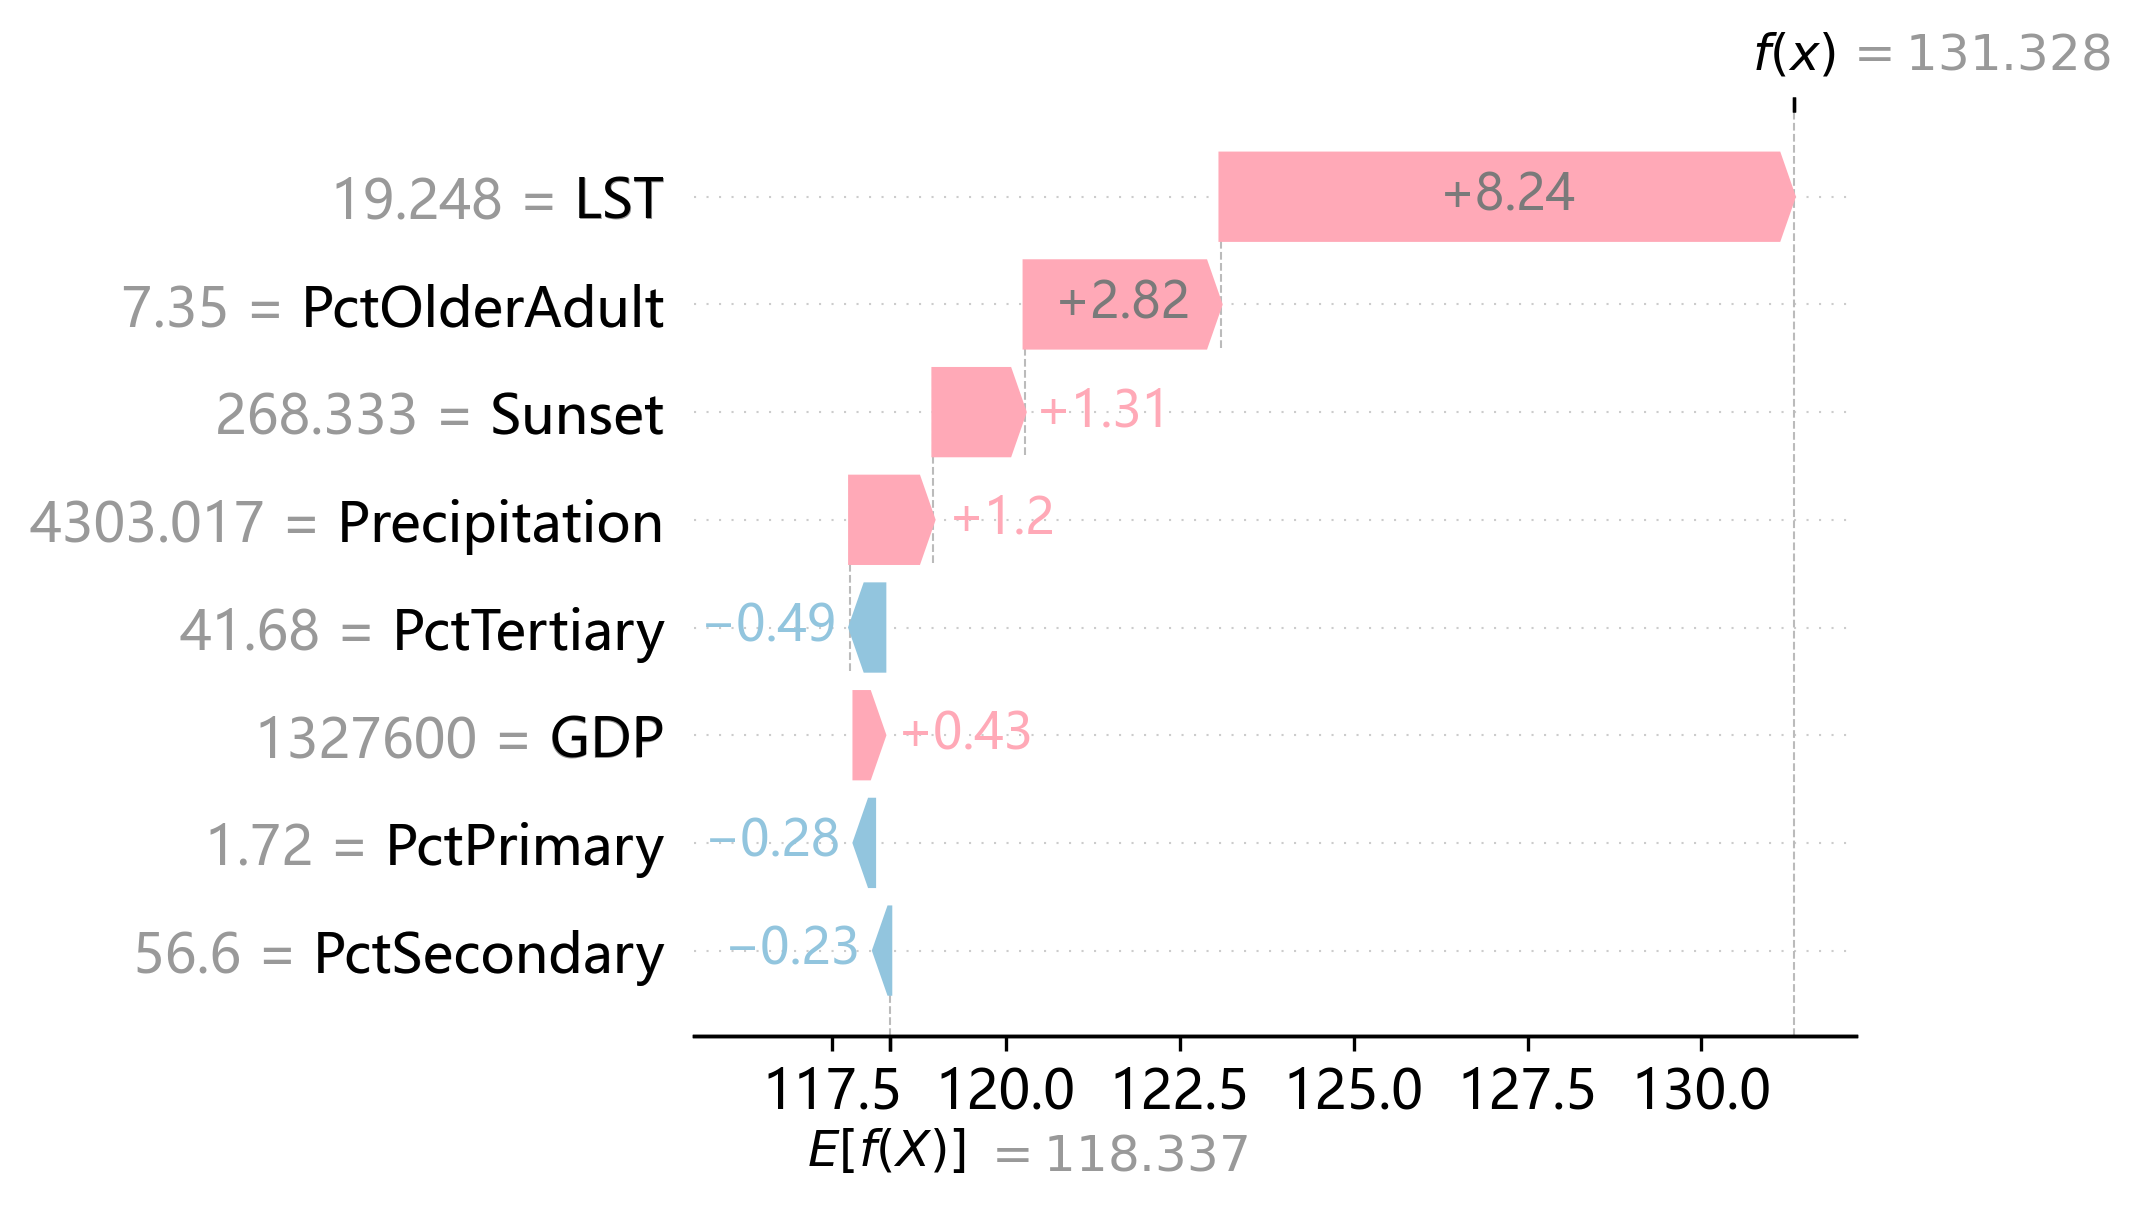

In [ ]:
import shap
import matplotlib.pyplot as plt
import matplotlib
import pandas as pd

matplotlib.rcParams['font.family'] = 'Microsoft YaHei'
matplotlib.rcParams['font.size'] = 18

# 1. 读取 Shapley 值和原始特征值
shapley = pd.read_csv(r'data/result3/shapley.csv', index_col='Unnamed: 0')
shapley = shapley.drop(columns='city')

var = pd.read_csv(r'data/result3/X.csv', index_col='Unnamed: 0')
var = var.drop(columns='city')

# 💡 【核心修改】：根据你的逻辑，计算所有城市预测值的平均值作为基础值
# 每行求和得到各城预测值，再求均值
base_value_calculated = data['NPI'].mean()

# 2. 找到广州对应的行位置
sh_idx = data.index[data['city'] == '佛山'][0]

# 3. 分别提取广州这一行的 [Shapley贡献值] 和 [特征实际值]
shap_values_row = shapley.iloc[sh_idx].to_numpy()
feature_values_row = var.iloc[sh_idx].to_numpy()     
feature_names = shapley.columns.tolist()

# 4. 手动封装成完美的 shap.Explanation 对象
shap_exp = shap.Explanation(
    values=shap_values_row,          # 这一行的每个特征贡献度
    base_values=base_value_calculated, # 👈 传入我们刚刚算出来的正确基础值
    data=feature_values_row,         # 图上显示 "特征 = 实际值"
    feature_names=feature_names      # 特征名称
)

# 5. 开始绘图
fig, ax = plt.subplots(figsize=(8, 8), dpi=300)

shap.plots.waterfall(
    shap_exp,
    max_display=20,           
    show=False
)
plt.gcf().set_size_inches(5, 4)

# 6. 【究极完美版】只移动第4行 + 保护底下小字不隐身
default_pos_color = "#ff0051"
default_neg_color = "#008bfb"

positive_fill = "#ffa9b7"
negative_fill = "#92c5de"
pos_edge = "#ffa9b7" 
neg_edge = "#92c5de"

for fc in plt.gcf().get_children():
    for fcc in fc.get_children():
        # A. 处理瀑布图的箭头
        if isinstance(fcc, matplotlib.patches.FancyArrow):
            current_hex = matplotlib.colors.to_hex(fcc.get_facecolor())
            if current_hex == default_pos_color:
                fcc.set_facecolor(positive_fill)   
                fcc.set_edgecolor(pos_edge)        
                fcc.set_linewidth(1.0)             
            elif current_hex == default_neg_color:
                fcc.set_facecolor(negative_fill)   
                fcc.set_edgecolor(neg_edge)        
                fcc.set_linewidth(1.0)             
                
        # B. 处理图上的文本
        elif isinstance(fcc, plt.Text):
            current_text_hex = matplotlib.colors.to_hex(fcc.get_color())
            text_str = fcc.get_text()
            
            # 把 Unicode 减号 '−' (\u2212) 也加进识别列表里
            if any(char in text_str for char in ['+', '-', '−']) and not 'f(x)' in text_str:
                x, y = fcc.get_position()
                y_row = round(y)  # 将纵坐标转换为整数行号
                
                # 🎯【特征一：对第 4 行（PctTertiary）强行向右推出去】
                if y_row == 4 and '+' in text_str:
                    fcc.set_color(positive_fill)         
                    fcc.set_horizontalalignment('left')  
                    fcc.set_position((x + 0.8, y))       # 稍微向右平移 0.5
                    continue                             
                
                # 🎯【特征二：对第 5 行（Sunset）强行向右推出去】
                elif y_row == 5 and '+' in text_str:
                    fcc.set_color(positive_fill)         # 👈 修正：既然是正数，换成优雅粉色
                    fcc.set_horizontalalignment('left')  # 👈 修正：左对齐，使其向右外面延伸
                    fcc.set_position((x + 0.8, y))       # 👈 修正：坐标加上0.5，往右平移到箭头外面
                    continue                             # 这一行处理完直接跳过
                
                # 🛡️【其余所有行的变色逻辑：尊重它们原来的内部/外部位置】
                is_white = current_text_hex.lower() in ['#ffffff', '#fff']
                
                if is_white:
                    # 原本在长箭头内部的白字，保持白色
                    fcc.set_color("#7A7A7A")
                else:
                    # 原本在外面的小字，直接根据正负强行上色
                    if '+' in text_str:
                        fcc.set_color(positive_fill)
                    else:
                        fcc.set_color(negative_fill)
plt.savefig('foshan.png', bbox_inches='tight',dpi=300)
plt.show()

In [ ]:
var['city'] = data['city']
var.to_csv(r'data/result3/X.csv')

C:\Users\Ke Entong\AppData\Local\Temp\ipykernel_20464\967006931.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  var['city'] = data['city']


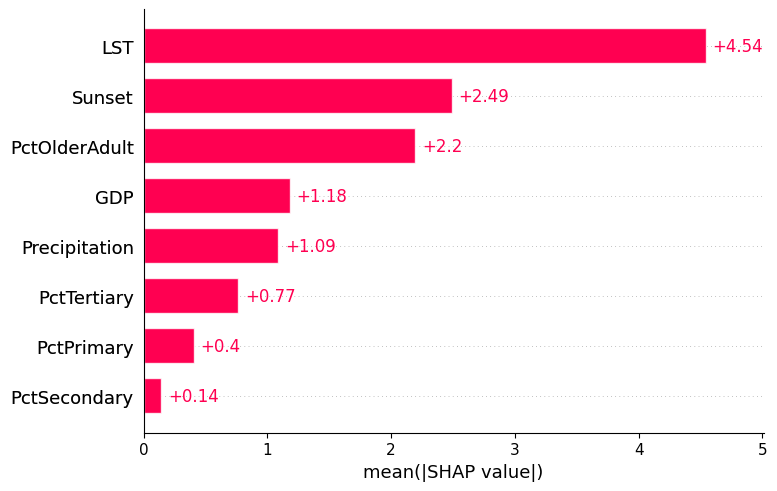

In [15]:
shap.plots.bar(geomlr_rslt)

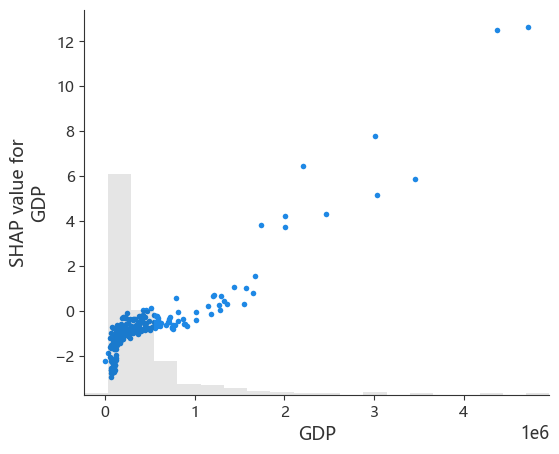

In [38]:
# geomlr_rslt.partial_dependence_plots(figsize=(12,6),max_cols=4,gam_curve=True)
shap.plots.scatter(geomlr_rslt[:, "GDP"])

In [25]:
var_list = ['LST', 'Precipitation', 'Sunset', 'GDP','PctOlderAdult', 'PctPrimary', 'PctSecondary', 'PctTertiary']

In [ ]:
import numpy as np



shapley = pd.DataFrame(geomlr_rslt.values, columns=var_list)



In [ ]:
shapley['city'] = data['city']
shapley.to_csv(r'data/result3/shapley.csv')
shapley

,LST,Precipitation,Sunset,GDP,PctOlderAdult,PctPrimary,PctSecondary,PctTertiary,city
0,14.030502,1.249600,-0.691108,-0.682697,-0.744787,0.391987,-0.279263,-0.530572,梅州
1,-2.852260,-1.776791,3.093884,-0.859838,2.129150,-0.156713,0.113718,-0.223028,吕梁
2,-1.988954,0.519215,-4.337643,-1.088534,-3.386105,-0.797914,-0.053131,-0.306151,舟山
3,-3.787508,-1.932785,-3.453215,-2.403144,-2.339932,-0.409068,-0.191092,-0.788796,朝阳
4,2.091036,0.857099,3.517734,-1.342516,-4.020154,0.261969,-0.061946,-0.548795,广安
...,...,...,...,...,...,...,...,...,...
271,-3.189105,-2.872347,3.564607,-2.244350,0.834943,-0.197214,-0.272199,-0.431983,陇南
272,-2.383802,-0.502983,3.133047,-0.951753,1.435568,0.238245,-0.019647,-0.282083,保山
273,2.277760,0.678648,3.125844,-1.285841,-3.832411,0.272799,-0.231216,-0.467808,遂宁
274,-3.196391,0.521652,-1.321926,0.238201,1.402803,-0.330734,0.108064,0.666379,合肥


In [ ]:
import pandas as pd

shapley = pd.read_csv(r'data/result3/shapley.csv', index_col='Unnamed: 0')
shapley = shapley.drop(columns='city')

In [ ]:
var = pd.read_csv(r'data/result3/X.csv', index_col='Unnamed: 0')
var = var.drop(columns='city')
var

,LST,Precipitation,Sunset,GDP,PctOlderAdult,PctPrimary,PctSecondary,PctTertiary
0,16.270223,3530.427525,280.250000,140800.0,14.41,18.89,31.53,49.58
1,5.479939,962.971386,259.266667,236600.0,11.62,4.64,67.35,28.01
2,13.088743,2625.939252,304.200000,210100.0,17.09,8.75,47.81,43.44
3,2.082538,1088.546691,296.016667,104400.0,15.96,23.79,27.95,48.26
4,14.556926,2823.592104,241.866667,151300.0,19.57,16.38,30.42,53.20
...,...,...,...,...,...,...,...,...
271,6.851463,989.385416,234.933333,60300.0,12.59,19.24,26.12,54.64
272,12.283457,2152.772421,212.366667,125400.0,12.59,23.57,36.45,39.98
273,14.617471,2579.975818,237.700000,171500.0,19.85,12.91,45.66,41.43
274,12.139336,2906.125367,284.133333,1267400.0,11.99,2.98,36.63,60.40


C:\Users\Admin\AppData\Local\Temp\ipykernel_23472\2294345623.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(data=shapley_melted,


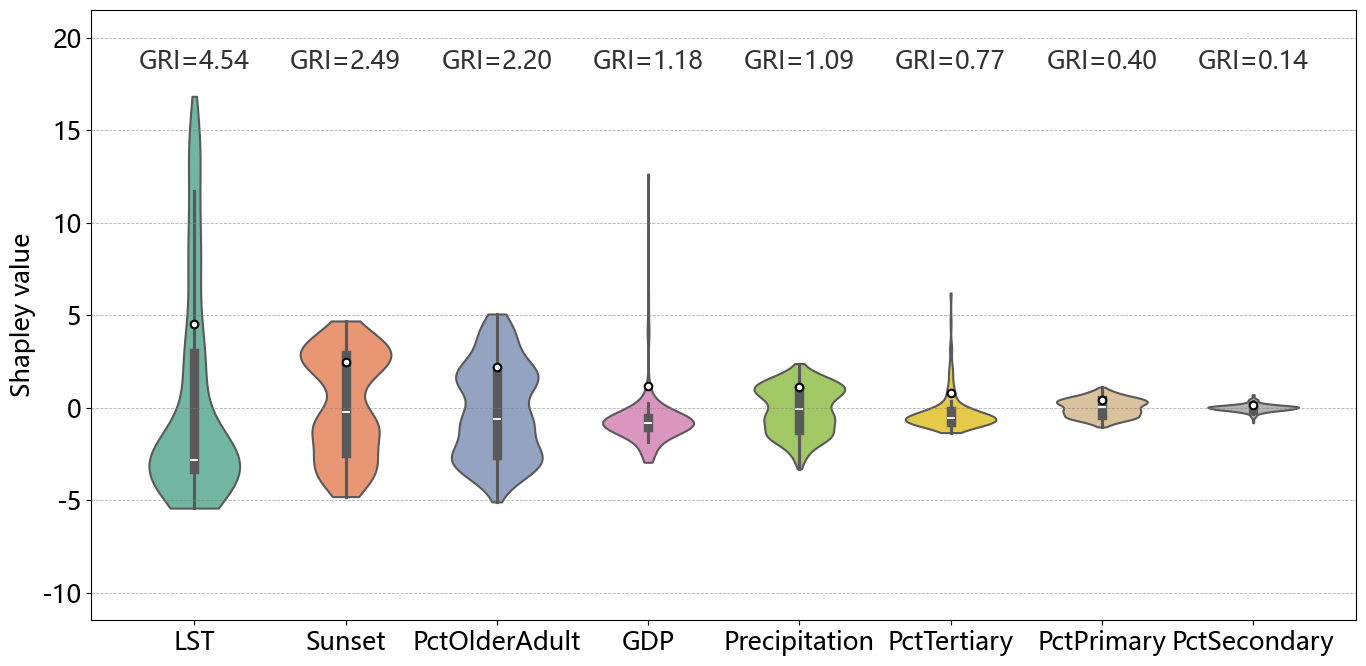

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib
import numpy as np


matplotlib.rcParams['font.family'] = 'Microsoft YaHei'
matplotlib.rcParams['font.size'] = 18


mean_abs = shapley.abs().mean().sort_values(ascending=False)
shapley_sorted = shapley[mean_abs.index]
shapley_melted = shapley_sorted.melt(var_name='Feature', value_name='Shapley Value')


plt.figure(figsize=(14, 7))
ax = sns.violinplot(data=shapley_melted,
                    x='Feature', y='Shapley Value',
                    palette='Set2',
                    cut=0,
                    inner='box', 
                    linewidth=1.5,
                    width=0.6)

plt.scatter(x=np.arange(len(mean_abs)),
            y=mean_abs.values,
            facecolors='white', 
            edgecolors='black',
            s=30,
            linewidths=1.5,
            zorder=3)


y_position = 18


for i, value in enumerate(mean_abs):
    ax.text(x=i,
            y=y_position, 
            s=f'GRI={value:.2f}',
            ha='center',
            va='bottom',
            fontsize=18,
            color='#333333',
            fontweight='regular')



yticks = plt.yticks()[0]
for y in yticks:
    plt.axhline(y=y, color='gray', linestyle='--', linewidth=0.6, alpha=0.6)


plt.xlabel("")
plt.ylabel("Shapley value")
plt.tight_layout()
# plt.savefig('factor_with_mean.png', bbox_inches='tight', dpi=300)
plt.show()

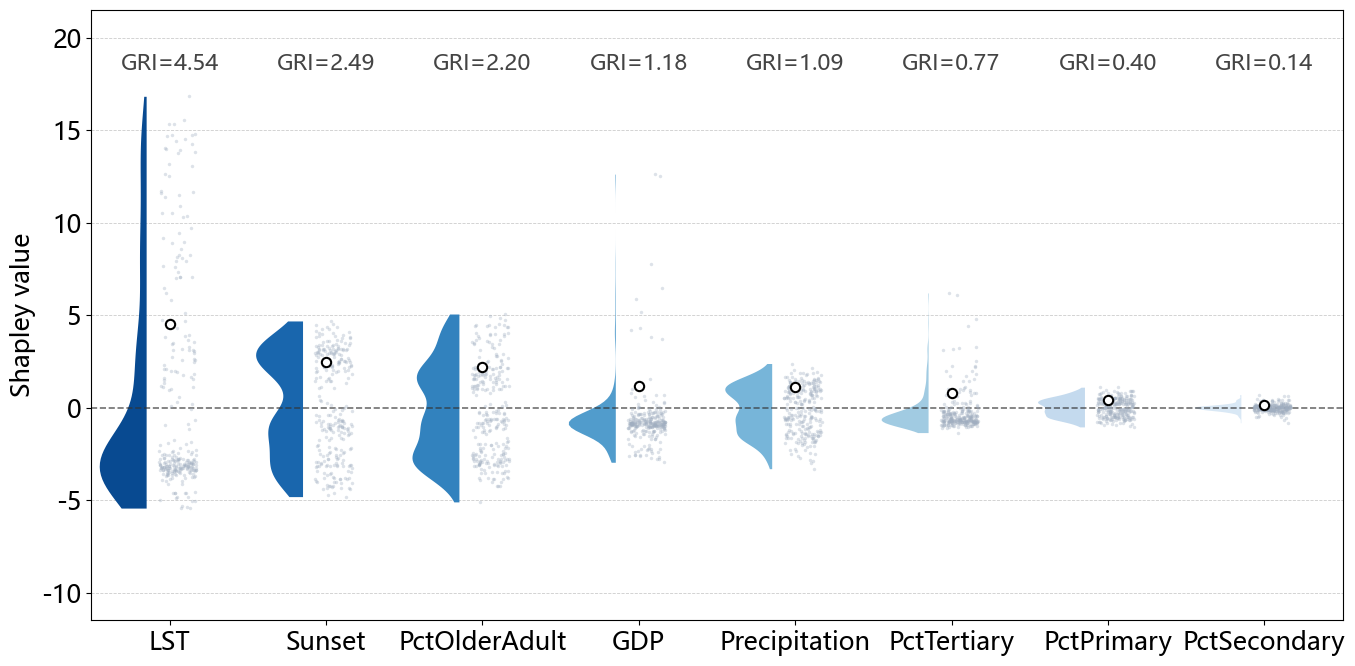

In [ ]:
import ptitprince as pt
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
import matplotlib.cm as cm

# 1. 基础画布与字体设置
matplotlib.rcParams['font.family'] = 'Microsoft YaHei'
matplotlib.rcParams['font.size'] = 18

# 数据处理（完全保留你原有的逻辑）
mean_abs = shapley.abs().mean().sort_values(ascending=False)
shapley_sorted = shapley[mean_abs.index]
shapley_melted = shapley_sorted.melt(var_name='Feature', value_name='Shapley Value')

fig, ax = plt.subplots(figsize=(14, 7))

color_range = np.linspace(0.1, 0.85, len(mean_abs))
gradient_palette = [cm.Blues_r(x) for x in color_range]

# ==================== 核心修改区域 ====================

# 2. 绘制“云”（半小提琴图）：彻底去掉内部箱体，并让形状饱满
pt.half_violinplot(
    x='Feature', 
    y='Shapley Value', 
    data=shapley_melted, 
    palette=gradient_palette,
    orient='v',
    width=0.6,          
    scale='width',      
    cut=0,              
    inner=None,         
    linewidth=0,        # 【优化】去掉小提琴图的黑边框，让渐变色块像云一样纯净
    ax=ax
)


# 3. 绘制“雨”（数据散点）：让雨滴紧贴在云的右侧
pt.stripplot(
    x='Feature', 
    y='Shapley Value', 
    data=shapley_melted, 
    color='#a0aec0',    # 【优化】雨滴不用彩色，统一用高质感炭灰色，告别色彩杂乱
    orient='v',
    size=2.5,           # 【优化】雨滴稍微变小，更显精致
    jitter=0.12,        # 稍微收敛抖动
    move=0.05,          # 恰到好处的右移，紧贴无边的云
    alpha=0.35,         # 【优化】调高透明度，当散点聚集时自然形成深浅浓淡效果
    ax=ax
)

# ====================================================

# 4. 叠加你原本的 GRI 均值点（白色中心、黑边的圆圈）
plt.scatter(
    x=np.arange(len(mean_abs)),
    y=mean_abs.values,
    facecolors='white', 
    edgecolors='black',
    s=45, 
    linewidths=1.5,
    zorder=3
)

# 5. 额外绘制一条 y=0 的粗虚线（对于 Shapley 值图来说，0 是一条非常重要的基准线）
plt.axhline(y=0, color='#333333', linestyle='--', linewidth=1.2, alpha=0.7, zorder=1)

# 6. GRI 文本标签
y_position = 18
for i, value in enumerate(mean_abs):
    ax.text(
        x=i,
        y=y_position, 
        s=f'GRI={value:.2f}',
        ha='center',
        va='bottom',
        fontsize=16, 
        color='#444444'
    )

# 7. 背景辅助网格线
yticks = plt.yticks()[0]
for y in yticks:
    if y != 0:  # 避免和 y=0 的基准线重叠
        plt.axhline(y=y, color='gray', linestyle='--', linewidth=0.6, alpha=0.4, zorder=0)

# 8. 轴标签与保存
plt.xlabel("")
plt.ylabel("Shapley value")
plt.tight_layout()
# plt.savefig('perfect_raincloud.png', bbox_inches='tight', dpi=300)
plt.show()

  0% (0 of 11) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--
 81% (9 of 11) |####################     | Elapsed Time: 0:00:00 ETA:   0:00:00
100% (11 of 11) |########################| Elapsed Time: 0:00:00 Time:  0:00:00
  0% (0 of 11) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--
 81% (9 of 11) |####################     | Elapsed Time: 0:00:00 ETA:   0:00:00
100% (11 of 11) |########################| Elapsed Time: 0:00:00 Time:  0:00:00
  0% (0 of 11) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--
 72% (8 of 11) |##################       | Elapsed Time: 0:00:00 ETA:   0:00:00
100% (11 of 11) |########################| Elapsed Time: 0:00:00 Time:  0:00:00
  0% (0 of 11) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--
 81% (9 of 11) |####################     | Elapsed Time: 0:00:00 ETA:   0:00:00
100% (11 of 11) |########################| Elapsed Time: 0:00:00 Time:  0:00:00
  0% (0 of 11) |                        

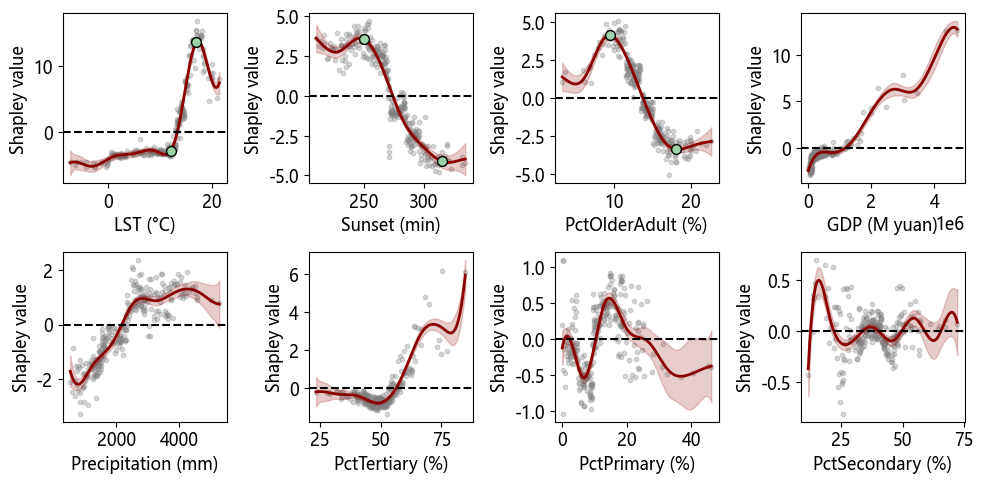

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from pygam import LinearGAM, s
import pandas as pd 

plt.rcParams['font.sans-serif'] = ['Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams.update({'font.size': 12})


units_list = [' (°C)', ' (mm)', ' (min)', ' (M yuan)', ' (%)', ' (%)', ' (%)', ' (%)']
mean_abs_shap = shapley.abs().mean().sort_values(ascending=False)
ordered_var_list = mean_abs_shap.index.tolist()


unit_map = dict(zip(var_list, units_list))
ordered_units_list = [unit_map[name] for name in ordered_var_list]



fig, axes = plt.subplots(2, 4, figsize=(10, 5), dpi=100)
axes = axes.flatten()
plt.subplots_adjust(wspace=0.4, hspace=0.3)


for ax, name, unit in zip(axes, ordered_var_list, ordered_units_list):
    x = var[name].values.reshape(-1, 1)
    y = shapley[name].values


    gam = LinearGAM(s(0, n_splines=10)).gridsearch(x, y)


    XX = np.linspace(x.min(), x.max(), 200)
    preds = gam.predict(XX)
    ci_lower, ci_upper = gam.confidence_intervals(XX, width=0.95).T


    ax.scatter(x, y, s=10, alpha=0.3, color='gray')


    ax.plot(XX, preds, color='darkred', linewidth=2)
    ax.fill_between(XX, ci_lower, ci_upper, color='darkred', alpha=0.2)

    ax.axhline(0, color='black', linestyle='--')

    ax.set_xlabel(name + unit)
    ax.set_ylabel('Shapley value')

    if name == 'LST':
        x_special = 12
        x_min, x_max = ax.get_xlim()
        if x_min <= x_special <= x_max:
            y_special = gam.predict([x_special])[0]

            ax.scatter(x_special, y_special, s=50, color='#9DD3A8', edgecolor='black', zorder=5)
        
        x_special2 = 17
        if x_min <= x_special2 <= x_max:
            y_special2 = gam.predict([x_special2])[0]

            ax.scatter(x_special2, y_special2, s=50, color='#9DD3A8', edgecolor='black', zorder=5)
    if name == 'Sunset':
        x_special = 250
        x_min, x_max = ax.get_xlim()
        if x_min <= x_special <= x_max:
            y_special = gam.predict([x_special])[0]

            ax.scatter(x_special, y_special, s=50, color='#9DD3A8', edgecolor='black', zorder=5)
        
        x_special2 = 315
        if x_min <= x_special2 <= x_max:
            y_special2 = gam.predict([x_special2])[0]

            ax.scatter(x_special2, y_special2, s=50, color='#9DD3A8', edgecolor='black', zorder=5)
    if name == 'PctOlderAdult':
        x_special = 9.5
        x_min, x_max = ax.get_xlim()
        if x_min <= x_special <= x_max:
            y_special = gam.predict([x_special])[0]

            ax.scatter(x_special, y_special, s=50, color='#9DD3A8', edgecolor='black', zorder=5)
        
        x_special2 = 18
        if x_min <= x_special2 <= x_max:
            y_special2 = gam.predict([x_special2])[0]

            ax.scatter(x_special2, y_special2, s=50, color='#9DD3A8', edgecolor='black', zorder=5)

plt.tight_layout()
# plt.savefig('plot/driving/pdp.png', dpi=300, bbox_inches='tight')
plt.show()

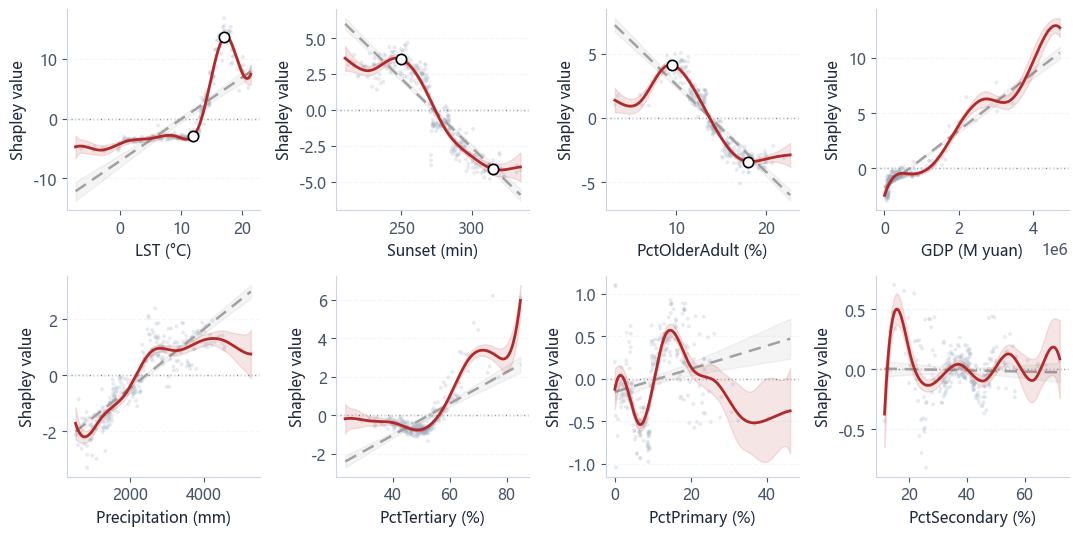

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from pygam import LinearGAM, s, l
import pandas as pd 

plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial', 'Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams.update({'font.size': 11})

units_list = [' (°C)', ' (mm)', ' (min)', ' (M yuan)', ' (%)', ' (%)', ' (%)', ' (%)']
mean_abs_shap = shapley.abs().mean().sort_values(ascending=False)
ordered_var_list = mean_abs_shap.index.tolist()

unit_map = dict(zip(var_list, units_list))
ordered_units_list = [unit_map[name] for name in ordered_var_list]

fig, axes = plt.subplots(2, 4, figsize=(11, 5.5), dpi=100)
axes = axes.flatten()
plt.subplots_adjust(wspace=0.4, hspace=0.35)

for ax, name, unit in zip(axes, ordered_var_list, ordered_units_list):
    x = var[name].values.reshape(-1, 1)
    y = shapley[name].values

    gam = LinearGAM(s(0, n_splines=10)).gridsearch(x, y, progress=False)
    gam_linear = LinearGAM(l(0)).gridsearch(x, y, progress=False)

    XX = np.linspace(x.min(), x.max(), 200)
    preds = gam.predict(XX)
    ci_lower, ci_upper = gam.confidence_intervals(XX, width=0.95).T
    
    preds_linear = gam_linear.predict(XX)
    ci_lower_linear, ci_upper_linear = gam_linear.confidence_intervals(XX, width=0.95).T

    ax.yaxis.grid(True, linestyle='--', color='#f1f5f9', alpha=0.8, zorder=0)

    ax.scatter(x, y, s=8, alpha=0.25, color='#a0aec0', edgecolors='none', zorder=2)


    ax.plot(XX, preds_linear, color="#A1A1A1", linestyle=(0, (5, 3)), linewidth=1.8, zorder=4)
    ax.fill_between(XX, ci_lower_linear, ci_upper_linear, color='#787878', alpha=0.08, zorder=3)


    ax.plot(XX, preds, color="#b02a2b", linewidth=2, zorder=6)
    ax.fill_between(XX, ci_lower, ci_upper, color='#b02a2b', alpha=0.12, zorder=5)

    # 4. Clean, thin zero reference line
    ax.axhline(0, color='#1e293b', linestyle=':', linewidth=1.0, alpha=0.6, zorder=1)

    # 5. Professional axis aesthetics
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#cbd5e1')
    ax.spines['bottom'].set_color('#cbd5e1')
    ax.tick_params(colors='#475569', width=0.8, direction='out')

    ax.set_xlabel(name + unit, fontsize=11, color='#1e293b')
    ax.set_ylabel('Shapley value', fontsize=11, color='#1e293b')

    if name == 'LST':
        x_special_points = [12, 17]
        for x_special in x_special_points:
            x_min, x_max = ax.get_xlim()
            if x_min <= x_special <= x_max:
                y_special = gam.predict([x_special])[0]
                ax.scatter(x_special, y_special, s=55, color='white', edgecolor="#000000", linewidth=1.2, zorder=7)
        
    elif name == 'Sunset':
        x_special_points = [250, 315]
        for x_special in x_special_points:
            x_min, x_max = ax.get_xlim()
            if x_min <= x_special <= x_max:
                y_special = gam.predict([x_special])[0]
                ax.scatter(x_special, y_special, s=55, color='white', edgecolor='#000000', linewidth=1.2, zorder=7)
            
    elif name == 'PctOlderAdult':
        x_special_points = [9.5, 18]
        for x_special in x_special_points:
            x_min, x_max = ax.get_xlim()
            if x_min <= x_special <= x_max:
                y_special = gam.predict([x_special])[0]
                ax.scatter(x_special, y_special, s=55, color='white', edgecolor='#000000', linewidth=1.2, zorder=7)

plt.tight_layout()
# plt.savefig('pdp.png', bbox_inches='tight', dpi=300)
plt.show()

In [13]:
import geopandas as gpd
local = gpd.GeoDataFrame(shapley, geometry=data['geometry'])


In [ ]:
local['city'] = data['city']
local['NPI'] = data['NPI']
local.to_file(r'data/result3/shapley.shp', encoding='utf-8')

C:\Users\Ke Entong\AppData\Local\Temp\ipykernel_20464\3544873828.py:3: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  local.to_file('regression/shapley.shp', encoding='utf-8')


In [ ]:
local = gpd.read_file(r'data/result3/shapley.shp')


local.rename(columns={
    'PctOlderAd': 'PctOlderAdult',
    'PctSeconda': 'PctSecondary',
    'PctTertiar': 'PctTertiary',
    'Precipitat': 'Precipitation'
}, inplace=True)

local

,LST,Precipitation,Sunset,GDP,PctOlderAdult,PctPrimary,PctSecondary,PctTertiary,city,NPI,geometry
0,14.030502,1.249600,-0.691108,-0.682697,-0.744787,0.391987,-0.279263,-0.530572,梅州,132,"POLYGON Z ((3172852.759 3024945.608 0.000, 317..."
1,-2.852260,-1.776791,3.093884,-0.859838,2.129150,-0.156713,0.113718,-0.223028,吕梁,120,"POLYGON Z ((2352673.622 4507687.604 0.000, 235..."
2,-1.988954,0.519215,-4.337643,-1.088534,-3.386105,-0.797914,-0.053131,-0.306151,舟山,102,MULTIPOLYGON Z (((3704161.177 3765051.612 0.00...
3,-3.787508,-1.932785,-3.453215,-2.403144,-2.339932,-0.409068,-0.191092,-0.788796,朝阳,101,"POLYGON Z ((2947975.461 5128461.903 0.000, 294..."
4,2.091036,0.857099,3.517734,-1.342516,-4.020154,0.261969,-0.061946,-0.548795,广安,119,MULTIPOLYGON Z (((2171518.404 3492793.408 0.00...
...,...,...,...,...,...,...,...,...,...,...,...
271,-3.189105,-2.872347,3.564607,-2.244350,0.834943,-0.197214,-0.272199,-0.431983,陇南,111,"POLYGON Z ((1905316.581 3929585.263 0.000, 190..."
272,-2.383802,-0.502983,3.133047,-0.951753,1.435568,0.238245,-0.019647,-0.282083,保山,119,"POLYGON Z ((1376855.172 2886172.787 0.000, 137..."
273,2.277760,0.678648,3.125844,-1.285841,-3.832411,0.272799,-0.231216,-0.467808,遂宁,117,MULTIPOLYGON Z (((2036812.985 3483897.241 0.00...
274,-3.196391,0.521652,-1.321926,0.238201,1.402803,-0.330734,0.108064,0.666379,合肥,117,"POLYGON Z ((3094538.255 3947390.977 0.000, 309..."


C:\Users\Ke Entong\AppData\Local\Temp\ipykernel_35316\3756707183.py:48: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


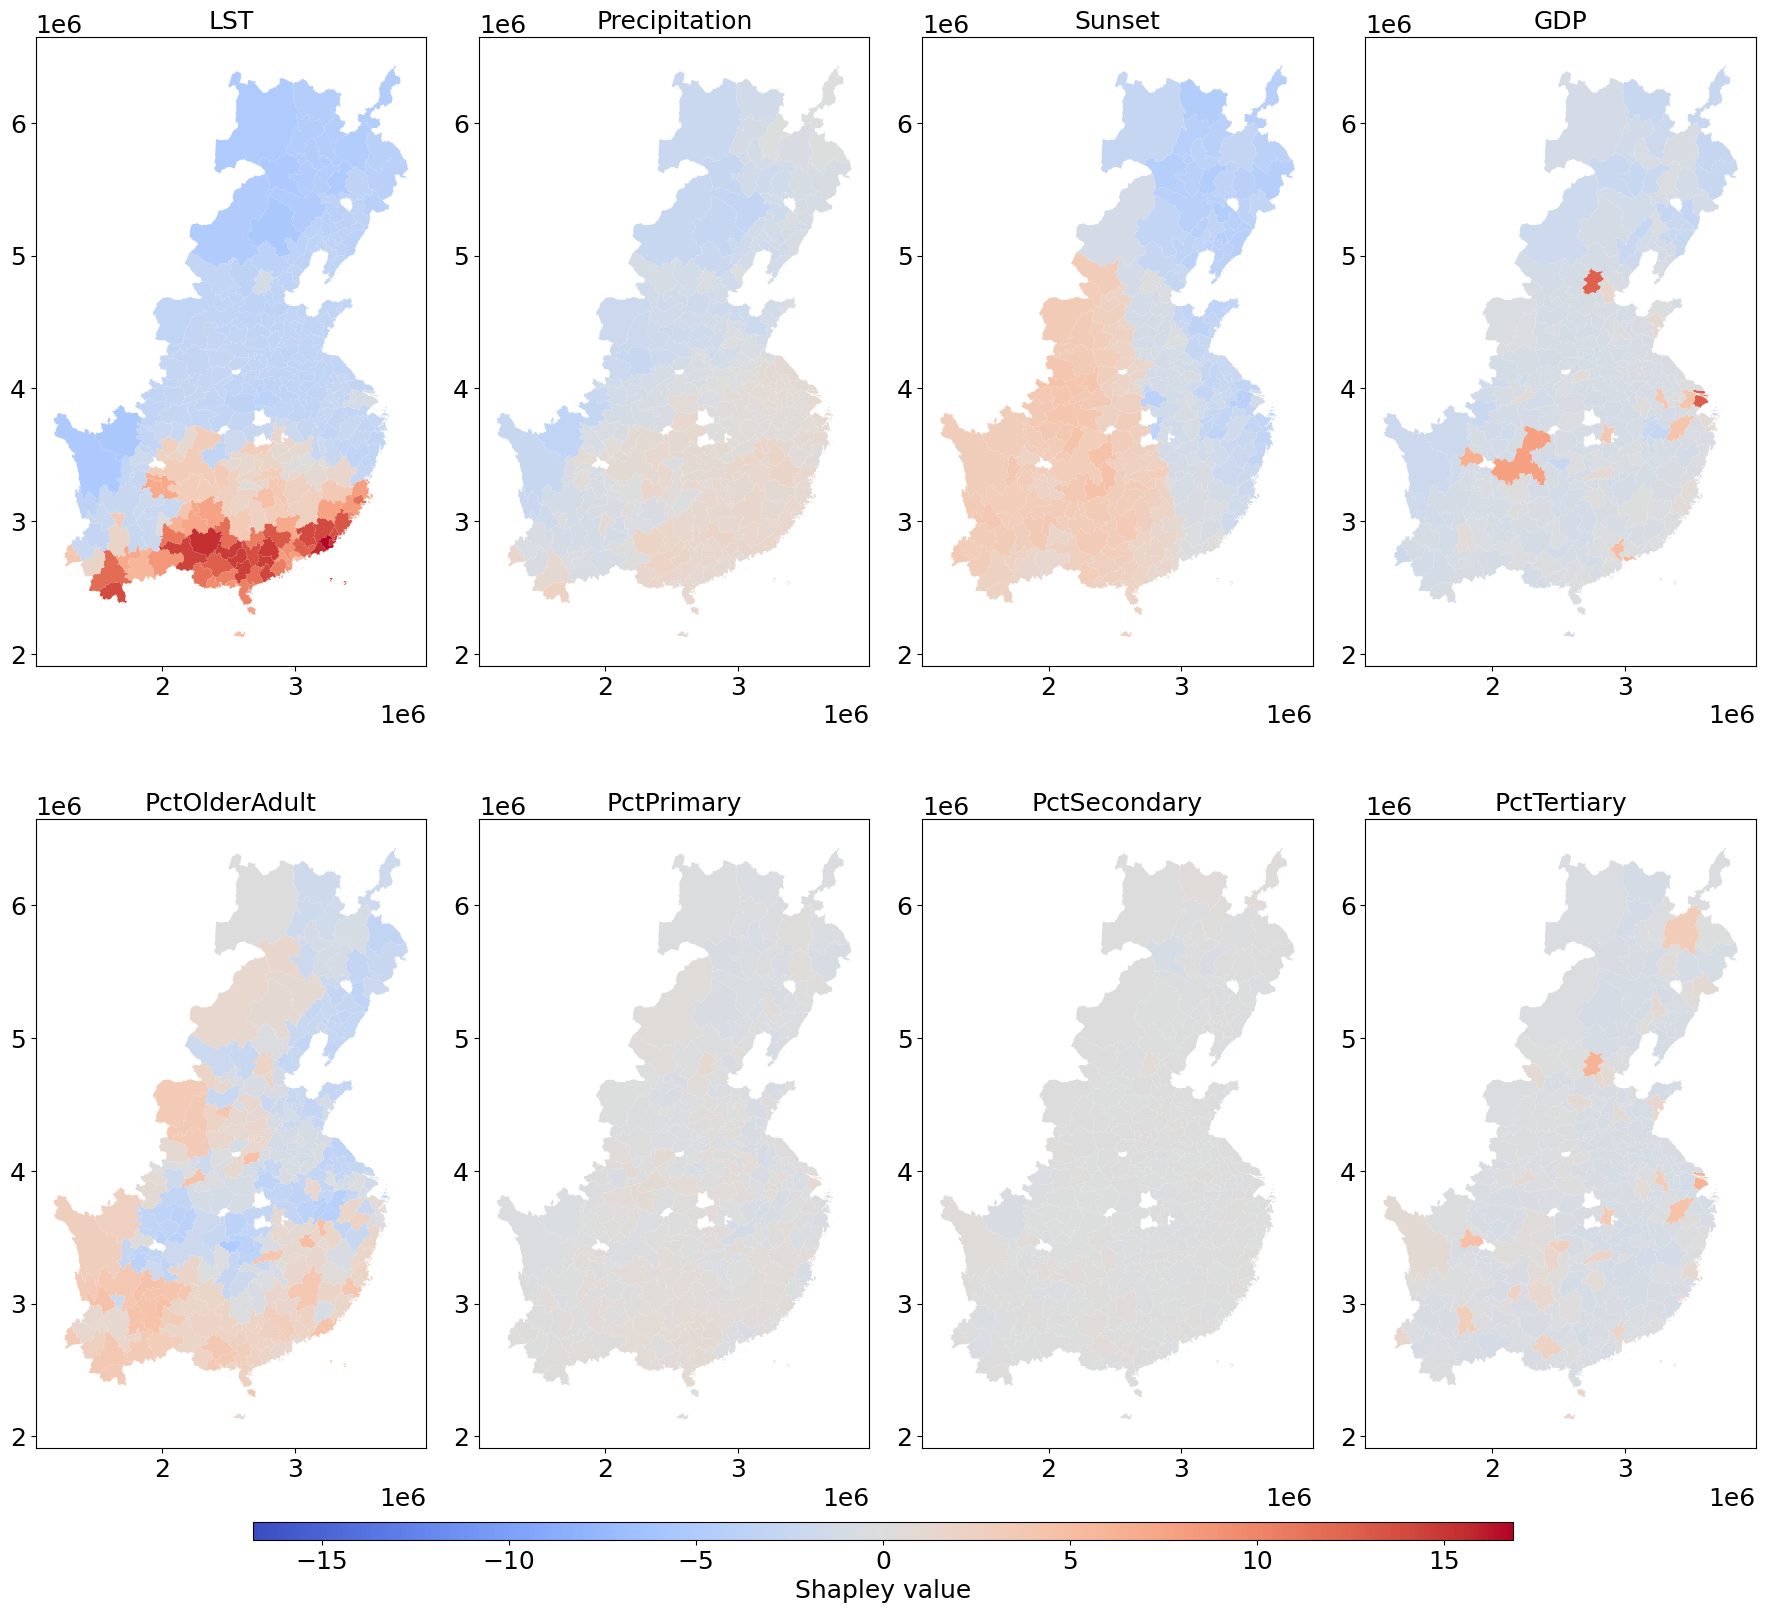

In [ ]:
import matplotlib.colors as colors

plt.rcParams.update({
    "font.size": 18,   
    "axes.titlesize": 18, 
    "axes.labelsize": 18, 
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 18
})

fig, axes = plt.subplots(2, 4, figsize=(18, 16))
axes = axes.flatten() 


vmin = local[var_list].min().min()
vmax = local[var_list].max().max()
norm = colors.Normalize(vmin=-vmax, vmax=vmax)


for i, field in enumerate(var_list):
    if i < len(axes): 
        local.plot(
            column=field,
            cmap='coolwarm',
            ax=axes[i],
            legend=False,
            norm=norm
        )
        axes[i].set_title(field)

for j in range(len(var_list), len(axes)):
    fig.delaxes(axes[j])


cbar_ax = fig.add_axes([0.15, 0.01, 0.7, 0.011])
cbar = fig.colorbar(
    plt.cm.ScalarMappable(norm=norm, cmap='coolwarm'),
    cax=cbar_ax,
    orientation='horizontal'
)

cbar.set_label('Shapley value')
plt.tight_layout()
plt.savefig(r"plot/S/shap_spatial.jpg", dpi=300, bbox_inches="tight")
plt.show()